# **Análisis del paisaje de optimización para el caso de 5 cúbits**

En esta sección se realizará un análisis del paisaje de optimización para el caso de 5 cúbits.
- Se estudiará el paisaje para una profundidad de circuito de $p = 2$ variando 2 y fijando el resto.
- Se estudiará el paisaje para una profundidad de cirrcuito de $p = 1$ normalizando el Hamiltoniano de Coste.
- Se reducirá los dominios de $\beta$ y $\gamma$ con el fin de ampliar el paisaje de energía en una zona.

In [ ]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

from tqdm.notebook import tqdm


In [2]:
seed = 99

In [3]:
N5 = 48567227

In [4]:
fiveQubit = sl.schnorrCVP(N5, 3, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 50


## **Definición del circuito**

In [5]:
instance = fiveQubit.generate_cvp(10)
babResult = fiveQubit.babai_algorithm(instance, 0.75)

B = 
[ 2 0 0 0 0  693 ]
[ 0 1 0 0 0 1099 ]
[ 0 0 3 0 0 1609 ]
[ 0 0 0 2 0 1946 ]
[ 0 0 0 0 1 2398 ]
t = 
(0, 0, 0, 0, 0, 17698)


In [6]:
qubo = qaoa.define_qubo(babResult.D, babResult.res_vector, babResult.step_sign, fiveQubit.n)
Hc, offset = qaoa.define_hamiltonian(qubo)
print(f'Offset = {offset}')
print(f'Hamiltonian = \n{Hc}')

Offset = 182.5
Hamiltonian = 
SparsePauliOp(['IIIIZ', 'IIZII', 'ZIIII', 'IIIZI', 'IZIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-33.5+0.j, -11. +0.j, -29.5+0.j, -20. +0.j, -50. +0.j,   7. +0.j,
 -10.5+0.j,  12. +0.j,   9.5+0.j,  -4.5+0.j,  15. +0.j,  -9. +0.j,
   1. +0.j,  -4.5+0.j,   0.5+0.j])


## **Pruebas para el problema del Grid**

### **1. Repetir para p > 1**

In [7]:
p = 2
circuitp2 = qaoa.construct_circuit(Hc, reps = p)

In [8]:
_, resultp2 = qaoa.qaoa_algorithm(circuitp2, Hc)
print(resultp2)

{'β[0]': np.float64(0.7419084576907897), 'β[1]': np.float64(-0.21518058329212345), 'γ[0]': np.float64(-0.01789061824762945), 'γ[1]': np.float64(-0.1821121479238048)}


In [9]:
gridp2 = 300

variables = list(resultp2.keys())
fixed = list(resultp2.values())

betabound = (0, np.pi)
gammabound = (0, 2*np.pi)

gridsp2 = {var: np.linspace(0, np.pi, gridp2) if i < p else np.linspace(0, 2*np.pi, gridp2) for i, var in enumerate(variables)}

beta_ticklabel = (["0", "π/2", "π"], [0, np.pi/2, np.pi])
gamma_ticklabel = (["0", "π/2", "π", "3π/2", "2π"], [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])

cmap = cm.viridis

In [ ]:
all_z = {}
for i, var_y in tqdm(enumerate(variables), desc = "var_y"):
    for j, var_x in tqdm(enumerate(variables), desc = "var_x"):
        if i == j:
            grid_args = []
            ngrid_args = []
            for v in gridsp2[var_y]:
                args = fixed.copy()
                args[i] = v
                grid_args.append(args)

            vals = qaoa.evaluate_params(circuitp2, Hc, grid_args)

            all_z[(i, i)] = vals

        else:
            gy = gridsp2[var_y]
            gx = gridsp2[var_x]

            X, Y = np.meshgrid(gx, gy)

            search_space = np.column_stack([X.ravel(), Y.ravel()])

            grid_args = []
            ngrid_args = []
            for point in search_space:
                args = fixed.copy()
                args[j] = point[0]
                args[i] = point[1]


                grid_args.append(args)

            vals = qaoa.evaluate_params(circuitp2, Hc, grid_args)

            all_z[(i, j)] = vals.reshape(gridp2, gridp2)


var_y: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

In [11]:
vminp2 = min(Z.min() for Z in all_z.values())
vmaxp2 = max(Z.max() for Z in all_z.values())
normp2 = Normalize(vmin=vminp2, vmax=vmaxp2)

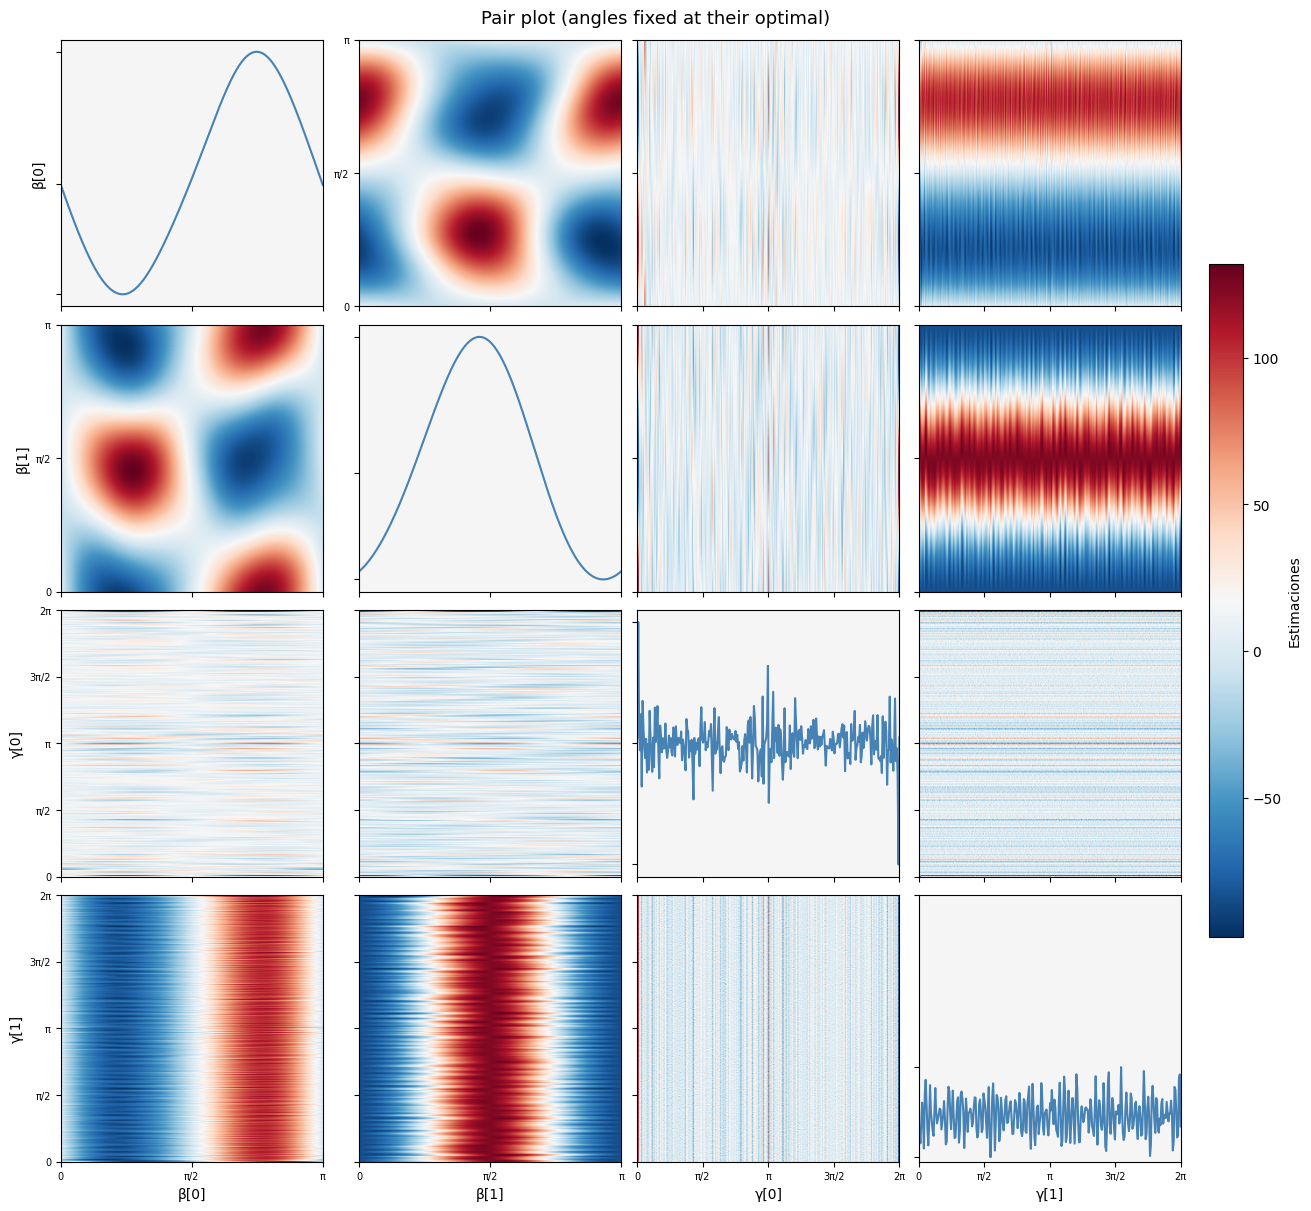

In [22]:
figp2, axesp2 = plt.subplots(4, 4, figsize = (13, 12), constrained_layout=True)

figp2.suptitle("Pair plot (angles fixed at their optimal)", fontsize = 13)

for i, var_y in enumerate(variables):
    gy = gridsp2[var_y]
    lo_y, hi_y = betabound if i < p else gammabound
    labels_y, ticks_y = beta_ticklabel if i < p else gamma_ticklabel

    for j, var_x in enumerate(variables):
        ax = axesp2[i][j]
        gx = gridsp2[var_x]

        lo_x, hi_x = betabound if j < p else gammabound

        labels_x, ticks_x = beta_ticklabel if j < p else gamma_ticklabel

        if i == j:
            vals = []

            for v in gridsp2[var_y]: 
                args = [fixed[k] % np.pi if k < p else fixed[k] % (2*np.pi) for k in range(4)]
                args[i] = v
                vals.append(qaoa.evaluate_params(circuitp2, Hc, args))

            ax.plot(gridsp2[var_y], all_z[(i, j)], color='steelblue', linewidth=1.5)
            ax.set_xlim(lo_y, hi_y)
            ax.set_facecolor("#f5f5f5ff")

            vals_min = min(all_z[(i, j)])
            vals_max = max(all_z[(i, j)])

            ax.set_yticks([vals_min, 0, vals_max])
            ax.set_yticklabels([])

            
        else:
            Z = all_z[(i, j)]

            ax.imshow(Z, origin='lower', aspect='auto', cmap="RdBu_r", 
                      extent=[lo_x, hi_x, lo_y, hi_y])
            
            #ax.plot(fixed[j] % np.pi if j < p else fixed[j] % (2*np.pi), fixed[i]% np.pi if i < p else fixed[i]% (2*np.pi), 'r*', markersize=8)

            ax.set_yticks(ticks_y)
            if j == 0 and i > 0:
                ax.set_yticklabels(labels_y, fontsize=7)
            elif j == 1 and i == 0: 
                ax.set_yticklabels(labels_y, fontsize = 7, ha = 'right')
            else:
                ax.set_yticklabels([], fontsize = 7)
        

        

        ax.set_xticks(ticks_x)
        ax.set_xticklabels(labels_x if i == 2*p - 1 else [], fontsize=7)

        

        if i == 2*p - 1:
            ax.set_xlabel(var_x, fontsize=10)
        if j == 0:
            ax.set_ylabel(var_y, fontsize=10)
        



#figp2.subplots_adjust(right=0.88, top=0.90, hspace=0.15, wspace=0.15)

figp2.colorbar(cm.ScalarMappable( norm = normp2, cmap="RdBu_r"),
             ax=axesp2, label='Estimaciones', shrink=0.6, pad=0.02)

#figp2.tight_layout()

figp2.savefig("figures/5Qubit_PruebasGrid_aumentarCapas_p2.png", dpi=150)

plt.show()
        

### **2. Normalizar el Hamiltoniano**

In [12]:
nHc, _ = qaoa.define_hamiltonian(qubo)
Hc_coeffs = nHc.coeffs
hnorm = np.max(np.abs(Hc_coeffs))
nHc.coeffs = Hc_coeffs / hnorm

print(nHc)

SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'ZIIII', 'IZIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-0.96116505+0.j, -0.74757282+0.j, -1.        +0.j,  0.15533981+0.j,
 -0.78640777+0.j,  0.13592233+0.j,  0.17475728+0.j,  0.17475728+0.j,
 -0.03883495+0.j,  0.31067961+0.j, -0.04854369+0.j, -0.0776699 +0.j,
  0.2815534 +0.j, -0.0776699 +0.j, -0.14563107+0.j])


In [13]:
circuit2 = qaoa.construct_circuit(nHc, reps = 1)

In [14]:
grid = 300

betha_grid = np.linspace(0, np.pi, grid)
gamma_grid = np.linspace(0, 2*np.pi, grid)

B, G = np.meshgrid(betha_grid, gamma_grid)

param_vals = np.column_stack([B.ravel(), G.ravel()])

In [15]:
evals = qaoa.evaluate_params(circuit2, nHc, param_vals)

Z = evals.reshape(grid, grid)

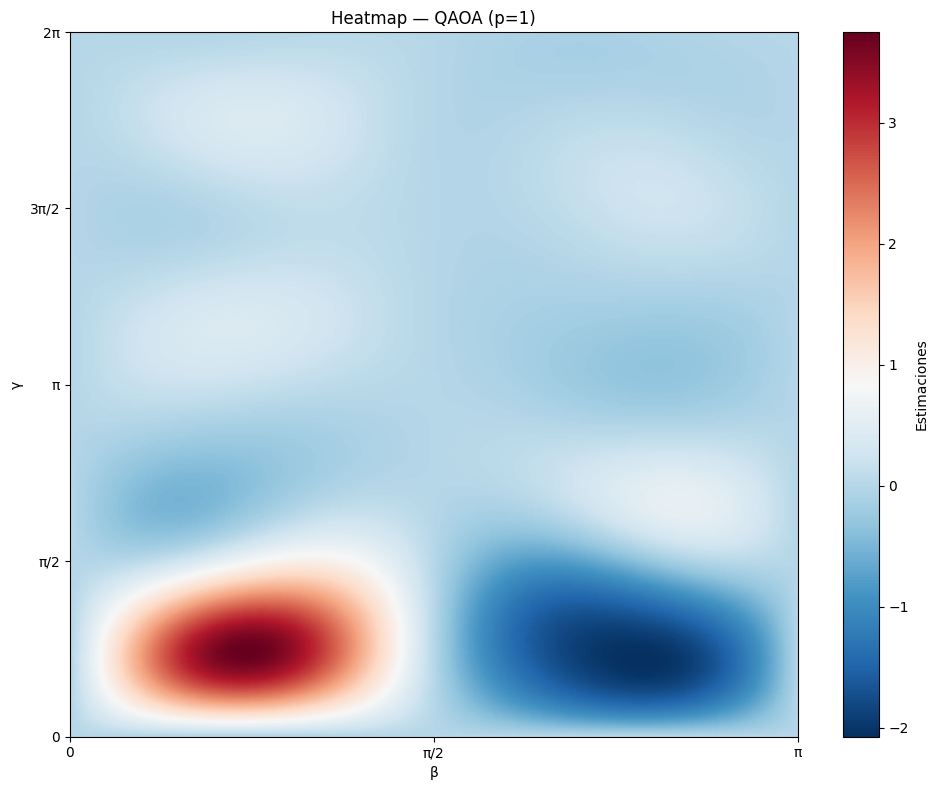

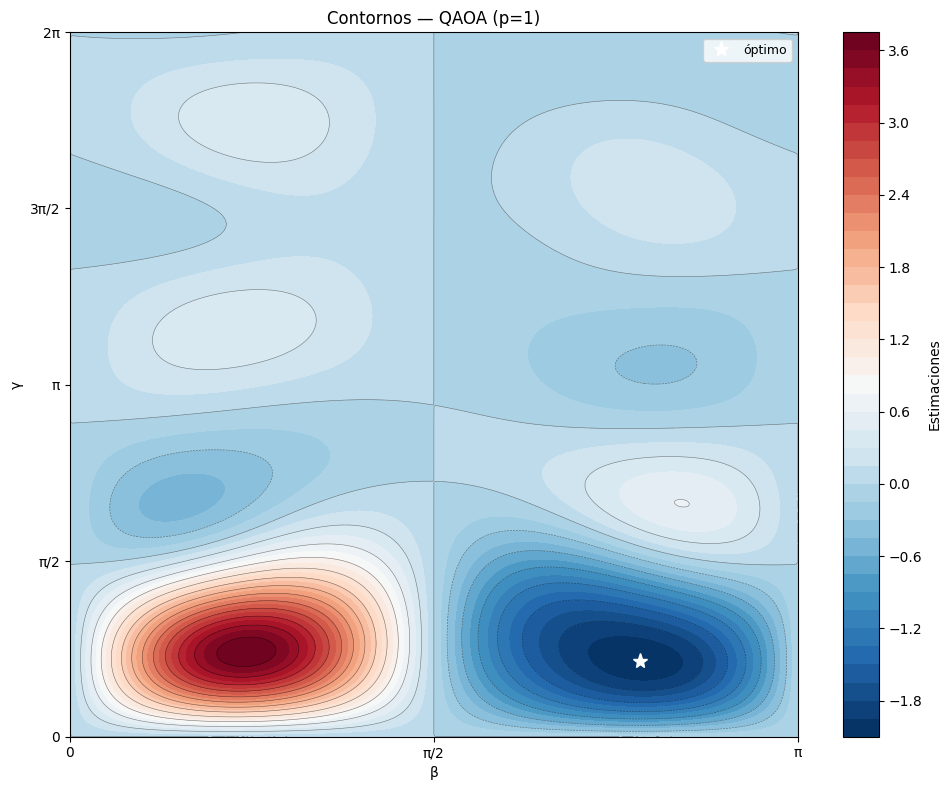

In [16]:
ticks_b = [0, np.pi/2, np.pi]
ticks_g = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

lbls_b = ["0", "π/2", "π"]
lbls_g = ["0", "π/2", "π", "3π/2", "2π"]

def _format_ax(ax):
    ax.set_xticks(ticks_b); ax.set_xticklabels(lbls_b)
    ax.set_yticks(ticks_g); ax.set_yticklabels(lbls_g)
    ax.set_xlabel("β"); ax.set_ylabel("γ")

# — Figura 1: heatmap ───────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 8))
im = ax1.imshow(
    Z, origin="lower", aspect="auto",
    extent=[0, np.pi, 0, 2*np.pi],
    cmap="RdBu_r", vmin = Z.min(), vmax= Z.max()
)
fig1.colorbar(im, ax=ax1, label="Estimaciones")
_format_ax(ax1)
ax1.set_title(f"Heatmap — QAOA (p={1})")
fig1.tight_layout()
fig1.savefig("figures/5Qubit_PruebasGrid_NormalizarHamiltoniano_Heatmap.png", dpi=150)



fig2, ax2 = plt.subplots(figsize=(10, 8))
cf = ax2.contourf(B, G, Z, levels=40, cmap="RdBu_r", vmin=Z.min(), vmax=Z.max())
ax2.contour(B, G, Z, levels=20, colors="k", linewidths=0.4, alpha=0.5)

idx = np.unravel_index(Z.argmin(), Z.shape)
ax2.plot(B[idx], G[idx], "w*", ms=11, label="óptimo")
ax2.legend(fontsize=9)

fig2.colorbar(cf, ax=ax2, label="Estimaciones")
_format_ax(ax2)
ax2.set_title(f"Contornos — QAOA (p={1})")
fig2.tight_layout()
fig2.savefig("figures/5Qubit_PruebasGrid_NormalizarHamiltoniano_Contornos.png", dpi=150)


plt.show()

In [17]:
print(Z.min())

-2.0730414684581437


In [18]:
i = np.unravel_index(Z.argmin(), Z.shape)
print(B[i])
print(G[i])

2.4586377288963597
0.6724479258519959


In [19]:
_, result = qaoa.qaoa_algorithm(circuit2, nHc)
print(result)

{'β[0]': np.float64(-0.68071690319925), 'γ[0]': np.float64(0.681939455187623)}


In [20]:
norm_value = qaoa.evaluate_params(circuit2, nHc, result)
print(norm_value * hnorm)    

-106.77860149045061


In [21]:
orCircuit = qaoa.construct_circuit(Hc, reps = 1)
_, orresult = qaoa.qaoa_algorithm(orCircuit, Hc)
print(orresult)

{'β[0]': np.float64(-0.6807056417341553), 'γ[0]': np.float64(0.013240339945990914)}


In [22]:
minimumValue = qaoa.evaluate_params(orCircuit, Hc, orresult)
print(f'MinimumValue = {minimumValue}')

MinimumValue = -106.77860168512478


### **3. Reducir rango de ángulos**

In [23]:
gamma_range = (-np.pi/4, np.pi/4)
beta_range = (-np.pi/4, np.pi/4)

p = 1
circuito = qaoa.construct_circuit(Hc, reps = p)

In [24]:
grid = 300

beta_grid = np.linspace(beta_range[0], beta_range[1], grid)
gamma_grid = np.linspace(gamma_range[0], gamma_range[1], grid)

B, G = np.meshgrid(beta_grid, gamma_grid)

params = np.column_stack([B.ravel(), G.ravel()])


In [25]:
evals = qaoa.evaluate_params(circuito, Hc, params)


Z = evals.reshape(grid, grid)

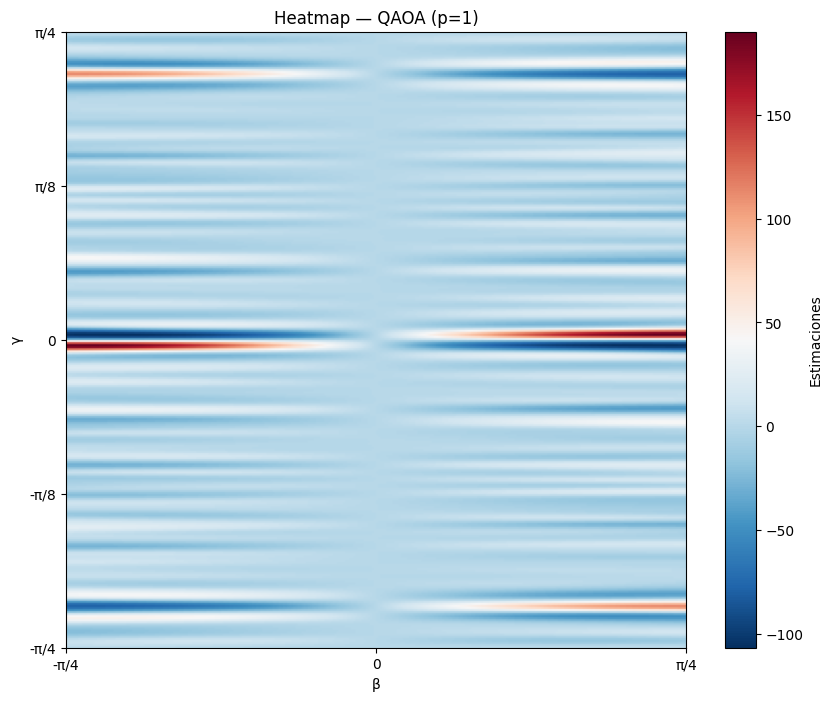

In [ ]:
ticks_b = [-np.pi/4, 0, np.pi/4]
ticks_g = [-np.pi/4, -np.pi/8, 0, np.pi/8, np.pi/4]

lbls_b = ["-π/4", "0", "π/4"]
lbls_g = ["-π/4", "-π/8", "0", "π/8", "π/4"]

def _format_ax(ax):
    ax.set_xticks(ticks_b); ax.set_xticklabels(lbls_b)
    ax.set_yticks(ticks_g); ax.set_yticklabels(lbls_g)
    ax.set_xlabel("β"); ax.set_ylabel("γ")

# — Figura 1: heatmap ───────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 8))
im = ax1.imshow(
    Z, origin="lower", aspect="auto",
    extent=[-np.pi/4, np.pi/4, -np.pi/4, np.pi/4],
    cmap="RdBu_r", vmin=Z.min(), vmax=Z.max()
)
fig1.colorbar(im, ax=ax1, label="Estimaciones")
_format_ax(ax1)
ax1.set_title(f"Heatmap — QAOA (p={1})")
#fig1.tight_layout()
fig1.savefig("figures/5Qubit_PruebasGrid_ReducirLimites.png", dpi=150)


plt.show()